In [1]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_token_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel_ExtraInfo_TimeDiffTower/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel_ExtraInfo_TimeDiffTower/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel_ExtraInfo_TimeDiffTower\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_TimeDiffTower\\"


#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
def get_vectorized_murphy(y_true_multiclasse, y_prob_matriz, top_n=600, n_bins=10):
    """
    Calcula as métricas de Murphy de forma vetorizada, corrigindo o
    shape de arrays dinâmicos e espelhando a discretização exata do pd.cut.
    """
    N_amostras = len(y_true_multiclasse)
    if N_amostras == 0:
        return pd.DataFrame()

    # 1. Identificar Top Tokens presentes estritamente neste slice
    tokens, counts = np.unique(y_true_multiclasse, return_counts=True)
    sort_idx = np.argsort(-counts)

    top_tokens_ids = tokens[sort_idx][:top_n]
    top_counts = counts[sort_idx][:top_n]

    # A CORREÇÃO CRÍTICA DO SHAPE:
    actual_n = len(top_tokens_ids)

    # 2. Isolar matrizes para os tokens filtrados
    P = y_prob_matriz[:, top_tokens_ids]
    Y = (y_true_multiclasse[:, None] == top_tokens_ids).astype(float)

    # 3. Taxas Base e Incerteza
    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    # 4. Discretização exata equivalente ao pd.cut(include_lowest=True)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    # digitize com right=True aloca valores <= à borda direita do bin
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    # Vetores dimensionados corretamente para o slice atual
    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = (bins == b) # booleano (N_amostras, actual_n)
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        # np.where é mais seguro e direto que multiplicar float por bool
        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        true_fraction = np.zeros(actual_n)
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras
        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid])**2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid])**2

    brier_score = reliability - resolution + uncertainty

    return pd.DataFrame({
        'token_id': top_tokens_ids,
        'frequencia': top_counts,
        'brier_score_multinomial': brier_score,
        'reliability_erro': reliability,
        'resolution_poder': resolution,
        'uncertainty_caos': uncertainty
    })

def get_vectorized_murphy_all_classes(y_true_multiclasse, y_prob_matriz, classes=None, n_bins=10):
    """
    Calcula a decomposição de Murphy considerando todas as classes possíveis.
    Isso evita perder reliability de classes não observadas no y_true do grupo,
    mas que receberam probabilidade positiva do modelo.
    """
    N_amostras = len(y_true_multiclasse)

    if N_amostras == 0:
        return pd.DataFrame()

    if classes is None:
        classes = np.arange(y_prob_matriz.shape[1])

    classes = np.asarray(classes)

    P = y_prob_matriz[:, classes]
    Y = (y_true_multiclasse[:, None] == classes).astype(float)

    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    actual_n = len(classes)

    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = bins == b
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        true_fraction = np.zeros(actual_n)

        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras

        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid]) ** 2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid]) ** 2

    brier_decomp = reliability - resolution + uncertainty

    frequencia = Y.sum(axis=0).astype(int)

    return pd.DataFrame({
        "token_id": classes,
        "frequencia": frequencia,
        "brier_score_multinomial": brier_decomp,
        "reliability_erro": reliability,
        "resolution_poder": resolution,
        "uncertainty_caos": uncertainty
    })

def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def multiclass_cross_entropy(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(np.log(y_prob[np.arange(len(y_true)), y_true]))

def process_group(idx, dev_y, all_probs, classes = None, get_bs_global = False, get_ce = False, get_mae = False):
    y_true_sub = dev_y[idx]
    y_prob_sub = all_probs[idx]

    if classes is None:
        classes = np.arange(y_prob_sub.shape[1])

    df_res = get_vectorized_murphy_all_classes(y_true_multiclasse=y_true_sub, y_prob_matriz = y_prob_sub, classes = classes, n_bins = 10)

    if get_bs_global:
        bs_global = multiclass_brier_score(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["brier_score_multinomial"] = bs_global

    if get_ce:
        ce_global = multiclass_cross_entropy(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["cross_entropy"] = ce_global

    if get_mae:
        expected_output = y_prob_sub @ np.arange(y_prob_sub.shape[1])
        mae_global = np.mean(np.abs(y_true_sub - expected_output))
        df_res["mae"] = mae_global

    return df_res

def multiclass_brier_score(y_true, y_prob):
    """
    Calcula o Brier Score Global para classificação multiclasse.

    y_true: array 1D com os índices reais dos tokens, shape (N,)
    y_prob: array 2D com as probabilidades preditas (softmax), shape (N, C)
    """
    N_amostras, n_classes = y_prob.shape

    # Cria a representação one-hot dos alvos (0.0 para erro, 1.0 para acerto)
    y_true_one_hot = np.zeros_like(y_prob, dtype=float)
    y_true_one_hot[np.arange(N_amostras), y_true] = 1.0

    # Calcula o erro quadrático, soma por classe e tira a média por amostra
    brier_score = np.mean(np.sum((y_prob - y_true_one_hot)**2, axis=1))

    return brier_score

def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


In [2]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}


In [3]:
%run 01_functions_training.ipynb

In [4]:
with open(data_folder + 'data_token_features.pkl', 'rb') as f:
    df_token_features = pickle.load(f)

In [5]:
with open(data_folder + 'dict_set_covariables.pkl', 'rb') as f:
    dict_set_covariables = pickle.load(f)

In [7]:
list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_TimeDiffTower" in item and ".pth" in item]
list_checks = [item for item in list_models if "embedding32" in item and "numlayers3" in item and "nodropout" in item and "layernormFalse" in item]

In [8]:
list_checks

['NGramModel_ExtraInfo_TimeDiffTower_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth',
 'NGramModel_ExtraInfo_TimeDiffTower_seasondata201920_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth',
 'NGramModel_ExtraInfo_TimeDiffTower_seasondata202021_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth',
 'NGramModel_ExtraInfo_TimeDiffTower_seasondata202122_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth',
 'NGramModel_ExtraInfo_TimeDiffTower_seasondata202223_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth']

In [11]:
list_seasons_val = ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
list_seasons_test = ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24']

In [17]:
list_decomposition_time_trn = []
list_decomposition_time_test = []
list_decomposition_season_trn = []
list_decomposition_season_test = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
VOCAB_SIZE = 601

for model_filename, season_val, season_test in zip(list_checks, list_seasons_val, list_seasons_test):
    print(model_filename, season_val, season_test)

    # 1. Carrega modelo
    CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
    EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
    variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
    num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
    num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
    dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
    layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

    index_num_covariables = dict_set_covariables["index"][5]
    num_covariables = dict_set_covariables["covariables"][5]

    index_tower_covariables = dict_set_covariables["index"][6]
    tower_covariables = dict_set_covariables["covariables"][6]

    token_model = NGramModel_ExtraInfo_TimeDiffTower(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE,
                                                        embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(index_num_covariables),
                                                        time_diff_input_dim = len(index_tower_covariables), time_tower_hidden_dim = 16,
                                                        time_tower_out_dim = 16, num_hidden_neurons = num_hidden_neurons, num_layers = num_layers,
                                                        activation = nn.GELU, dropout_rate = dropout_rate, use_layer_norm = layer_norm)

    token_model.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
    token_model.eval()

    # 2. define dados treino e teste
    # 2.1. define dados treino
    df_ = df_token_features.query("season == @season_val").query("season_split == 'train'")\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))\
    .pipe(get_match_splits, num_secs = 200)

    trn_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
    trn_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    trn_y = df_["target_tokens"].values
    trn_mask = torch.tensor(build_logit_mask_ngram_models(df_), dtype = torch.bool, device = device)

    # 2.2. define dados teste
    df_test = df_token_features.query("season == @season_test")\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))\
    .pipe(get_match_splits, num_secs = 200)

    test_tkn = torch.from_numpy(np.stack(df_test["token_features"].values)).to(torch.int64)
    test_num = torch.from_numpy(np.stack(df_test["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    test_y = df_test["target_tokens"].values
    test_mask = torch.tensor(build_logit_mask_ngram_models(df_test), dtype = torch.bool, device = device)

    # 3. inferencia  para o treino e para o teste
    with torch.no_grad():
        # Ajuste condicional para modelos que requerem variáveis numéricas
        output_model_trn = token_model(trn_tkn[:, -CONTEXT_SIZE:], trn_num[:, index_tower_covariables], trn_num[:, index_num_covariables])
        output_model_trn = output_model_trn.masked_fill(trn_mask, -1e9)

        all_probs_trn = torch.softmax(output_model_trn, dim = 1).cpu().numpy()
        ######################################
        # Ajuste condicional para modelos que requerem variáveis numéricas
        output_model_test = token_model(test_tkn[:, -CONTEXT_SIZE:], test_num[:, index_tower_covariables], test_num[:, index_num_covariables])
        output_model_test = output_model_test.masked_fill(test_mask, -1e9)

        all_probs_test = torch.softmax(output_model_test, dim = 1).cpu().numpy()

    # 4. extraindo metricas por faixa de 20secs
    # treino
    results_time_trn = []
    for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = trn_y, all_probs = all_probs_trn, get_bs_global = True, get_ce = True)
        res_df["season_split"] = name[0]
        res_df["period"] = name[1]
        res_df["cat_time"] = name[2]
        results_time_trn.append(res_df)

    df_decomposition_by_time_trn = pd.concat(results_time_trn, ignore_index = True)\
    .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
            set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
            num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
            seasondata = season_val)
    
    df_resultados_time_trn = df_decomposition_by_time_trn\
    .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
    [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
    .merge(df_decomposition_by_time_trn[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
    .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

    list_decomposition_time_trn.append(df_resultados_time_trn)
    
    # teste
    results_time_test = []
    for name, group_idx in df_test.groupby(["season", "period", "cat_time"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = test_y, all_probs = all_probs_test, get_bs_global = True, get_ce = True)
        res_df["season_split"] = "test"
        res_df["period"] = name[1]
        res_df["cat_time"] = name[2]
        results_time_test.append(res_df)

    df_decomposition_by_time_test = pd.concat(results_time_test, ignore_index = True)\
    .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
            set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
            num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
            seasondata = season_test)
    
    df_resultados_time_test = df_decomposition_by_time_test\
    .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
    [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
    .merge(df_decomposition_by_time_test[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
    .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))
    
    list_decomposition_time_test.append(df_resultados_time_test)

    # 5. extraindo metricas agregadas
    # treino
    results_split_trn = []
    for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = trn_y, all_probs = all_probs_trn, get_bs_global = True, get_ce = True)
        # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
        res_df["season_split"] = name
        results_split_trn.append(res_df)

    df_decomposition_by_split_trn = pd.concat(results_split_trn, ignore_index = True)\
    .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
            set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
            num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
            seasondata = season_val)

    df_resultados_split_trn = df_decomposition_by_split_trn\
    .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
    [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
    .merge(df_decomposition_by_split_trn[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
    .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

    list_decomposition_season_trn.append(df_resultados_split_trn)

    # teste
    results_split_test = []
    for name, group_idx in df_test.groupby(["season"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = test_y, all_probs = all_probs_test, get_bs_global = True, get_ce = True)
        # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
        res_df["season_split"] = "test"
        results_split_test.append(res_df)

    df_decomposition_by_split_test = pd.concat(results_split_test, ignore_index = True)\
    .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
            set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
            num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
            seasondata = season_test)

    df_resultados_split_test = df_decomposition_by_split_test\
    .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
    [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
    .merge(df_decomposition_by_split_test[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
    .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

    list_decomposition_season_test.append(df_resultados_split_test)




NGramModel_ExtraInfo_TimeDiffTower_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth 2018-19 2019-20
NGramModel_ExtraInfo_TimeDiffTower_seasondata201920_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth 2019-20 2020-21
NGramModel_ExtraInfo_TimeDiffTower_seasondata202021_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth 2020-21 2021-22
NGramModel_ExtraInfo_TimeDiffTower_seasondata202122_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth 2021-22 2022-23
NGramModel_ExtraInfo_TimeDiffTower_seasondata202223_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables56_parameters.pth 2022-23 2023-24


In [18]:
df_murphy_decomposition_by_time_trn = pd.concat(list_decomposition_time_trn, ignore_index = True)
df_murphy_decomposition_by_time_test = pd.concat(list_decomposition_time_test, ignore_index = True)

In [25]:
df_murphy_decomposition_by_time_trn.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TREINO.parquet", index = False, compression = "zstd")
df_murphy_decomposition_by_time_test.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_TESTE.parquet", index = False, compression = "zstd")

In [19]:
df_murphy_decomposition_by_season_split_trn = pd.concat(list_decomposition_season_trn, ignore_index = True)
df_murphy_decomposition_by_season_split_test = pd.concat(list_decomposition_season_test, ignore_index = True)

In [26]:
df_murphy_decomposition_by_season_split_trn.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TREINO.parquet", index = False, compression = "zstd")
df_murphy_decomposition_by_season_split_test.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split_TESTE.parquet", index = False, compression = "zstd")

In [30]:
models_token_metrics_folder

'G:\\Meu Drive\\mestrado_final_files\\metrics_models\\NGramModel_ExtraInfo_TimeDiffTower\\'

In [38]:
df_murphy_decomposition_by_time_val = pd.read_parquet(models_token_metrics_folder +  "murphy_decomposition_by_time.parquet")\
.query("embedding_layer_size == 32 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")

In [53]:
df_comparacao_final_token_evento = pd.merge(
    df_murphy_decomposition_by_time_trn\
    .query("period <= 4")\
    .groupby(["period", "cat_time"], as_index = False, dropna = False)[["cross_entropy", "bss"]].mean()\
    .rename(columns = {"cross_entropy": "cross_entropy_treino", "bss": "bss_treino"}),

    df_murphy_decomposition_by_time_val\
    .query("period <= 4")\
    .groupby(["period", "cat_time"], as_index = False, dropna = False)[["cross_entropy", "bss"]].mean()\
    .rename(columns = {"cross_entropy": "cross_entropy_val", "bss": "bss_val"}),

    how = "inner")\
.merge(
    df_murphy_decomposition_by_time_test\
    .query("period <= 4")\
    .groupby(["period", "cat_time"], as_index = False, dropna = False)[["cross_entropy", "bss"]].mean()\
    .rename(columns = {"cross_entropy": "cross_entropy_teste", "bss": "bss_teste"}),
    how = "inner")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int") / 10)





In [54]:
df_comparacao_final_token_evento

,period,cat_time,cross_entropy_treino,bss_treino,cross_entropy_val,bss_val,cross_entropy_teste,bss_teste,t1
0,1,0-200,2.170702,0.281588,2.317362,0.256922,2.310615,0.258810,0.0
1,1,1000-1200,2.734310,0.169940,2.855650,0.165594,2.773508,0.166251,100.0
2,1,1200-1400,2.769946,0.171521,2.807305,0.156995,2.809785,0.167651,120.0
3,1,1400-1600,2.813445,0.164974,2.888760,0.156337,2.862983,0.160003,140.0
4,1,1600-1800,2.855597,0.162739,2.886822,0.156793,2.917423,0.157935,160.0
...,...,...,...,...,...,...,...,...,...
139,4,6400-6600,2.760635,0.163286,2.783537,0.162384,2.805277,0.159018,640.0
140,4,6600-6800,2.708265,0.165588,2.805128,0.136577,2.758361,0.160423,660.0
141,4,6800-7000,2.672285,0.162955,2.727423,0.150198,2.711991,0.157620,680.0
142,4,7000-7200,2.849596,0.119131,2.813686,0.130250,2.910332,0.113223,700.0


In [43]:
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt


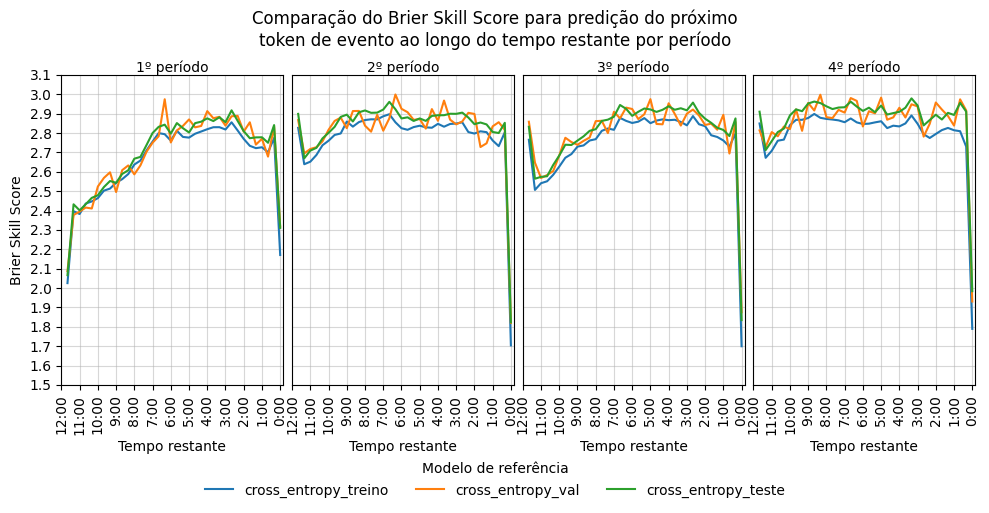

In [55]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_comparacao_final_token_evento\
    .query("period == (@i + 1)")\
    .sort_values("t1")\
    .set_index("t1")[["cross_entropy_treino", "cross_entropy_val", "cross_entropy_teste"]]\
    .plot(ax = ax[i], legend = False)

    bounds_y = [1.5, 3.1]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.1))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Comparação do Brier Skill Score para predição do próximo\ntoken de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

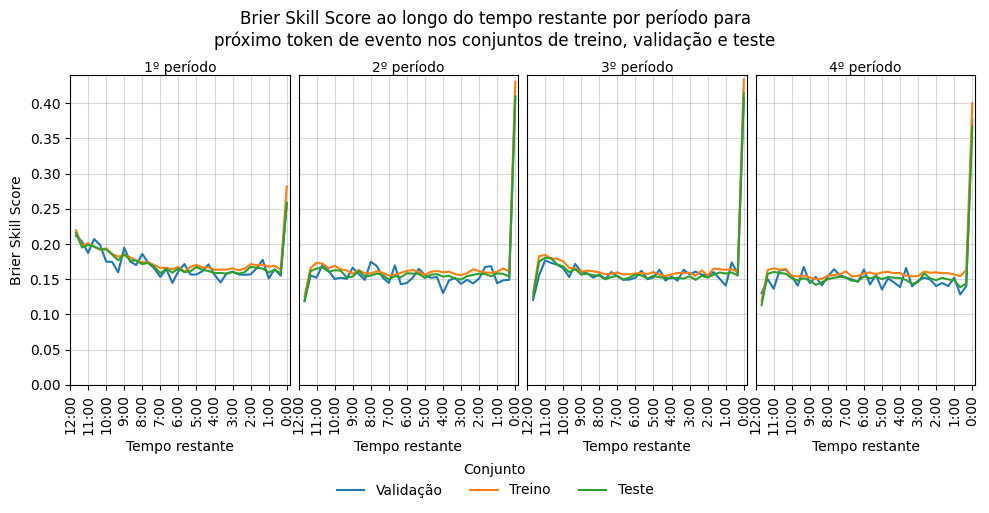

In [68]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_comparacao_final_token_evento\
    .query("period == (@i + 1)")\
    .sort_values("t1")\
    .set_index("t1")[["bss_val", "bss_treino", "bss_teste"]]\
    .plot(ax = ax[i], legend = False)

    bounds_y = [0, 0.44]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score ao longo do tempo restante por período para\npróximo token de evento nos conjuntos de treino, validação e teste", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["Validação", "Treino", "Teste"]
fig.legend(handles, labels, title = "Conjunto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [69]:
df_murphy_decomposition_by_season_split_trn\
[["reliability_erro", "resolution_poder", "uncertainty_caos", "cross_entropy", "brier_score_multinomial", "bss"]].describe()

,reliability_erro,resolution_poder,uncertainty_caos,cross_entropy,brier_score_multinomial,bss
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.000553,0.156543,0.962856,2.727560,0.791020,0.178466
std,0.000027,0.002086,0.000648,0.012049,0.002651,0.002266
min,0.000515,0.153655,0.962148,2.712860,0.787564,0.175320
25%,0.000547,0.155683,0.962228,2.716425,0.790176,0.177481
50%,0.000550,0.156844,0.962983,2.733195,0.790348,0.178806
75%,0.000563,0.157196,0.963327,2.736109,0.792355,0.179271
max,0.000588,0.159339,0.963594,2.739212,0.794657,0.181452


In [24]:
df_murphy_decomposition_by_season_split_test\
[["reliability_erro", "resolution_poder", "uncertainty_caos", "cross_entropy", "brier_score_multinomial", "bss"]].describe()

,reliability_erro,resolution_poder,uncertainty_caos,cross_entropy,brier_score_multinomial,bss
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.000888,0.151899,0.962827,2.786454,0.796818,0.172419
std,0.000078,0.003225,0.000606,0.014283,0.003771,0.003475
min,0.000772,0.147993,0.962202,2.768693,0.792346,0.168424
25%,0.000840,0.149043,0.962211,2.777702,0.794771,0.169275
50%,0.000935,0.152874,0.962904,2.786993,0.795498,0.173252
75%,0.000944,0.154292,0.963322,2.792874,0.800401,0.174610
max,0.000947,0.155295,0.963497,2.806010,0.801075,0.176536


### Modelo de tempo gasto

In [71]:
data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel_MultiTowers\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_MultiTowers\\"


In [76]:
with open(data_folder + 'data_time_features.pkl', 'rb') as f:
    df_time_features = pickle.load(f)

In [72]:
list_models = [item for item in os.listdir(models_time_folder) if "SpentTimeModel_" in item and ".pth" in item]
list_checks = [item for item in list_models if "embedding32" in item and "numlayers3" in item and "nodropout" in item and "layernormTrue" in item]

In [74]:
VOCAB_SIZE = 601
TIME_SIZE = 301

In [80]:
list_TIME_decomposition_time_trn = []
list_TIME_decomposition_time_test = []
list_TIME_decomposition_season_trn = []
list_TIME_decomposition_season_test = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
VOCAB_SIZE = 601

for model_filename, season_val, season_test in zip(list_checks, list_seasons_val, list_seasons_test):
    print(model_filename, season_val, season_test)

    # 1. Carrega modelo
    CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
    EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
    variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
    num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
    num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
    dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
    layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

    index_num_covariables1 = dict_set_covariables["index"][5]
    num_covariables1 = dict_set_covariables["covariables"][5]

    index_num_covariables2 = dict_set_covariables["index"][6]
    num_covariables2 = dict_set_covariables["covariables"][6]

    time_model = SpentTimeModel_MultiTowers(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE, 
                                            embedding_dim = EMBEDDING_LAYER_SIZE, numeric_input_dims = [len(index_num_covariables1), len(index_num_covariables2)],
                                            token_tower_dim = 32, numeric_tower_dims = 16, num_hidden_neurons = num_hidden_neurons, 
                                            num_layers = num_layers, activation_function = nn.GELU, dropout_rate = dropout_rate, 
                                            use_layer_norm = layer_norm)

    time_model.load_state_dict(torch.load(models_time_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
    time_model.eval()

    # 2. define dados treino e teste
    # 2.1. define dados treino
    df_ = df_time_features.query("season == @season_val").query("season_split == 'train'")\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))\
    .pipe(get_match_splits, num_secs = 200)

    trn_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
    trn_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    trn_y = df_["target_time"].values
    trn_mask = torch.tensor(build_logit_mask_spent_time_models(df_), dtype = torch.bool, device = device)

    # 2.2. define dados teste
    df_test = df_time_features.query("season == @season_test")\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))\
    .pipe(get_match_splits, num_secs = 200)

    test_tkn = torch.from_numpy(np.stack(df_test["token_features"].values)).to(torch.int64)
    test_num = torch.from_numpy(np.stack(df_test["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    test_y = df_test["target_time"].values
    test_mask = torch.tensor(build_logit_mask_spent_time_models(df_test), dtype = torch.bool, device = device)

    # 3. inferencia  para o treino e para o teste
    with torch.no_grad():
        # Ajuste condicional para modelos que requerem variáveis numéricas
        output_model_trn = time_model(trn_tkn[:, -CONTEXT_SIZE:], [trn_num[:, index_num_covariables1], trn_num[:, index_num_covariables2]])
        output_model_trn = output_model_trn.masked_fill(trn_mask, -1e9)

        all_probs_trn = torch.softmax(output_model_trn, dim = 1).cpu().numpy()
        ######################################
        # Ajuste condicional para modelos que requerem variáveis numéricas
        output_model_test = time_model(test_tkn[:, -CONTEXT_SIZE:], [test_num[:, index_num_covariables1], test_num[:, index_num_covariables2]])
        output_model_test = output_model_test.masked_fill(test_mask, -1e9)

        all_probs_test = torch.softmax(output_model_test, dim = 1).cpu().numpy()

    # 4. extraindo metricas por faixa de 20secs
    # treino
    results_time_trn = []
    for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = trn_y, all_probs = all_probs_trn, get_bs_global = True, get_ce = True, get_mae = True)
        res_df["season_split"] = name[0]
        res_df["period"] = name[1]
        res_df["cat_time"] = name[2]
        results_time_trn.append(res_df)

    df_decomposition_by_time_trn = pd.concat(results_time_trn, ignore_index = True)\
    .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
            set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
            num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
            seasondata = season_val)
    
    df_resultados_time_trn = df_decomposition_by_time_trn\
    .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
    [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
    .merge(df_decomposition_by_time_trn[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
    .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

    list_TIME_decomposition_time_trn.append(df_resultados_time_trn)
    
    # teste
    results_time_test = []
    for name, group_idx in df_test.groupby(["season", "period", "cat_time"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = test_y, all_probs = all_probs_test, get_bs_global = True, get_ce = True, get_mae = True)
        res_df["season_split"] = "test"
        res_df["period"] = name[1]
        res_df["cat_time"] = name[2]
        results_time_test.append(res_df)

    df_decomposition_by_time_test = pd.concat(results_time_test, ignore_index = True)\
    .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
            set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
            num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
            seasondata = season_test)
    
    df_resultados_time_test = df_decomposition_by_time_test\
    .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
    [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
    .merge(df_decomposition_by_time_test[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
    .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))
    
    list_TIME_decomposition_time_test.append(df_resultados_time_test)

    # 5. extraindo metricas agregadas
    # treino
    results_split_trn = []
    for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = trn_y, all_probs = all_probs_trn, get_bs_global = True, get_ce = True, get_mae = True)
        # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
        res_df["season_split"] = name
        results_split_trn.append(res_df)

    df_decomposition_by_split_trn = pd.concat(results_split_trn, ignore_index = True)\
    .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
            set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
            num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
            seasondata = season_val)

    df_resultados_split_trn = df_decomposition_by_split_trn\
    .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
    [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
    .merge(df_decomposition_by_split_trn[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
    .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

    list_TIME_decomposition_season_trn.append(df_resultados_split_trn)

    # teste
    results_split_test = []
    for name, group_idx in df_test.groupby(["season"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = test_y, all_probs = all_probs_test, get_bs_global = True, get_ce = True, get_mae = True)
        # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
        res_df["season_split"] = "test"
        results_split_test.append(res_df)

    df_decomposition_by_split_test = pd.concat(results_split_test, ignore_index = True)\
    .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
            set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
            num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
            seasondata = season_test)

    df_resultados_split_test = df_decomposition_by_split_test\
    .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
    [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
    .merge(df_decomposition_by_split_test[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial", "mae"]].drop_duplicates(), how = "left")\
    .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

    list_TIME_decomposition_season_test.append(df_resultados_split_test)




SpentTimeModel_MultiTowers_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormTrue_setcovariables56_parameters.pth 2018-19 2019-20
SpentTimeModel_MultiTowers_seasondata202223_context5_embedding32_numlayers3_numneurons50_nodropout_layernormTrue_setcovariables56_parameters.pth 2019-20 2020-21
SpentTimeModel_MultiTowers_seasondata201920_context5_embedding32_numlayers3_numneurons50_nodropout_layernormTrue_setcovariables56_parameters.pth 2020-21 2021-22
SpentTimeModel_MultiTowers_seasondata202122_context5_embedding32_numlayers3_numneurons50_nodropout_layernormTrue_setcovariables56_parameters.pth 2021-22 2022-23
SpentTimeModel_MultiTowers_seasondata202021_context5_embedding32_numlayers3_numneurons50_nodropout_layernormTrue_setcovariables56_parameters.pth 2022-23 2023-24


In [81]:
df_TIME_murphy_decomposition_by_time_trn = pd.concat(list_TIME_decomposition_time_trn, ignore_index = True)
df_TIME_murphy_decomposition_by_time_test = pd.concat(list_TIME_decomposition_time_test, ignore_index = True)

In [82]:
df_TIME_murphy_decomposition_by_time_trn.to_parquet(models_token_metrics_folder + "TIME_murphy_decomposition_by_time_TREINO.parquet", index = False, compression = "zstd")
df_TIME_murphy_decomposition_by_time_test.to_parquet(models_token_metrics_folder + "TIME_murphy_decomposition_by_time_TESTE.parquet", index = False, compression = "zstd")

In [83]:
df_TIME_murphy_decomposition_by_season_split_trn = pd.concat(list_TIME_decomposition_season_trn, ignore_index = True)
df_TIME_murphy_decomposition_by_season_split_test = pd.concat(list_TIME_decomposition_season_test, ignore_index = True)

In [84]:
df_TIME_murphy_decomposition_by_season_split_trn.to_parquet(models_token_metrics_folder + "TIME_murphy_decomposition_by_season_split_TREINO.parquet", index = False, compression = "zstd")
df_TIME_murphy_decomposition_by_season_split_test.to_parquet(models_token_metrics_folder + "TIME_murphy_decomposition_by_season_split_TESTE.parquet", index = False, compression = "zstd")

In [85]:
os.listdir(models_token_metrics_folder)

['murphy_decomposition_by_time.parquet',
 'murphy_decomposition_by_season_split.parquet',
 'murphy_decomposition_by_time_TIME_MODEL.parquet',
 'murphy_decomposition_by_season_split_TIME_MODEL.parquet',
 'murphy_decomposition_by_dif.parquet',
 'murphy_decomposition_by_dif_TIME_MODEL.parquet',
 'murphy_decomposition_by_time_dif_TIME_MODEL.parquet',
 'murphy_decomposition_by_time_dif.parquet',
 'TIME_murphy_decomposition_by_time_TREINO.parquet',
 'TIME_murphy_decomposition_by_time_TESTE.parquet',
 'TIME_murphy_decomposition_by_season_split_TREINO.parquet',
 'TIME_murphy_decomposition_by_season_split_TESTE.parquet',
 'desktop.ini']

In [86]:
df_TIME_murphy_decomposition_by_time_val = pd.read_parquet(models_token_metrics_folder +  "murphy_decomposition_by_time_TIME_MODEL.parquet")\
.query("embedding_layer_size == 32 & num_layers == 3 & dropout_rate == 0 & layer_norm == 1")

In [89]:
df_comparacao_final_spent_time = pd.merge(
    df_TIME_murphy_decomposition_by_time_trn\
    .query("period <= 4")\
    .groupby(["period", "cat_time"], as_index = False, dropna = False)[["cross_entropy", "bss", "mae"]].mean()\
    .rename(columns = {"cross_entropy": "cross_entropy_treino", "bss": "bss_treino", "mae": "mae_treino"}),

    df_TIME_murphy_decomposition_by_time_val\
    .query("period <= 4")\
    .groupby(["period", "cat_time"], as_index = False, dropna = False)[["cross_entropy", "bss", "mae"]].mean()\
    .rename(columns = {"cross_entropy": "cross_entropy_val", "bss": "bss_val", "mae": "mae_val"}),

    how = "inner")\
.merge(
    df_TIME_murphy_decomposition_by_time_test\
    .query("period <= 4")\
    .groupby(["period", "cat_time"], as_index = False, dropna = False)[["cross_entropy", "bss", "mae"]].mean()\
    .rename(columns = {"cross_entropy": "cross_entropy_teste", "bss": "bss_teste", "mae": 'mae_teste'}),
    how = "inner")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int") / 10)





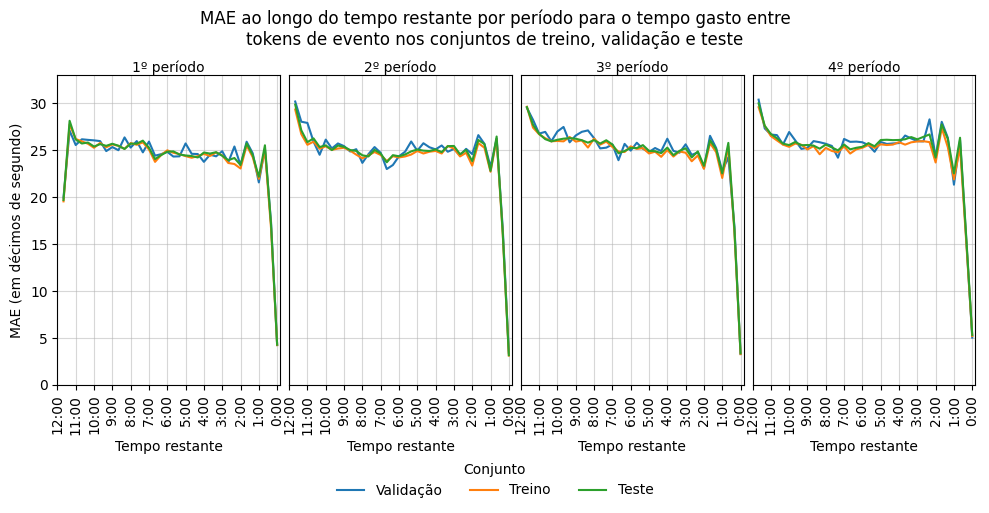

In [97]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_comparacao_final_spent_time\
    .query("period == (@i + 1)")\
    .sort_values("t1")\
    .set_index("t1")[["mae_val", "mae_treino", "mae_teste"]]\
    .plot(ax = ax[i], legend = False)

    bounds_y = [0, 33]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE (em décimos de segundo)")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("MAE ao longo do tempo restante por período para o tempo gasto entre\ntokens de evento nos conjuntos de treino, validação e teste", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["Validação", "Treino", "Teste"]
fig.legend(handles, labels, title = "Conjunto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [94]:
df_TIME_murphy_decomposition_by_season_split_trn\
[["reliability_erro", "resolution_poder", "uncertainty_caos", "cross_entropy", "brier_score_multinomial", "bss", "mae"]].describe()

,reliability_erro,resolution_poder,uncertainty_caos,cross_entropy,brier_score_multinomial,bss,mae
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.001672,0.139633,0.951150,2.344997,0.793652,0.165588,23.807692
std,0.000148,0.004072,0.000305,0.029248,0.004697,0.004715,0.373425
min,0.001498,0.134793,0.950724,2.305826,0.786840,0.160051,23.352625
25%,0.001558,0.137134,0.951043,2.324111,0.791910,0.162605,23.508991
50%,0.001684,0.139777,0.951124,2.356047,0.793871,0.165512,23.897625
75%,0.001751,0.140913,0.951327,2.361495,0.796398,0.167396,24.011062
max,0.001867,0.145549,0.951533,2.377506,0.799239,0.172378,24.268158


In [95]:
df_TIME_murphy_decomposition_by_season_split_test\
[["reliability_erro", "resolution_poder", "uncertainty_caos", "cross_entropy", "brier_score_multinomial", "bss", "mae"]].describe()

,reliability_erro,resolution_poder,uncertainty_caos,cross_entropy,brier_score_multinomial,bss,mae
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.001804,0.137570,0.951253,2.362566,0.796103,0.163101,24.026598
std,0.000156,0.002144,0.000379,0.008662,0.002311,0.002325,0.145278
min,0.001638,0.134645,0.950727,2.349757,0.792775,0.160110,23.914254
25%,0.001716,0.137193,0.951035,2.361031,0.795615,0.162724,23.917390
50%,0.001743,0.137285,0.951294,2.361310,0.796279,0.162885,23.955060
75%,0.001895,0.138105,0.951584,2.368084,0.796619,0.163151,24.096307
max,0.002028,0.140623,0.951625,2.372649,0.799226,0.166635,24.249978
